# Paper Plots

In [25]:
library(mvtnorm)
library(ggplot2)
source('~/isolines_uq/scripts/R/confidence_regions/modules/distributionIsolines.R')
source('~/isolines_uq/scripts/R/confidence_regions/modules/confidenceRegions.R')
source('~/isolines_uq/scripts/R/confidence_regions/modules/coverageEvaluation.R')
source('~/isolines_uq/scripts/R/confidence_regions/modules/visualizeTubes.R')

source('~/isolines_uq/scripts/R/confidence_regions/modules/utils.R')


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.8-40. For overview type 'help("mgcv-package")'.


Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count




In [19]:
multivariate_dat <- data.frame(rmvt(n=10000, df=4, sigma = matrix(c(1, 0.7, 0.7, 1), nrow=2)))
multivariate_isoline <- drawIsoline('bivt', 200, c(10,10), c(-2,-2), 0.001)

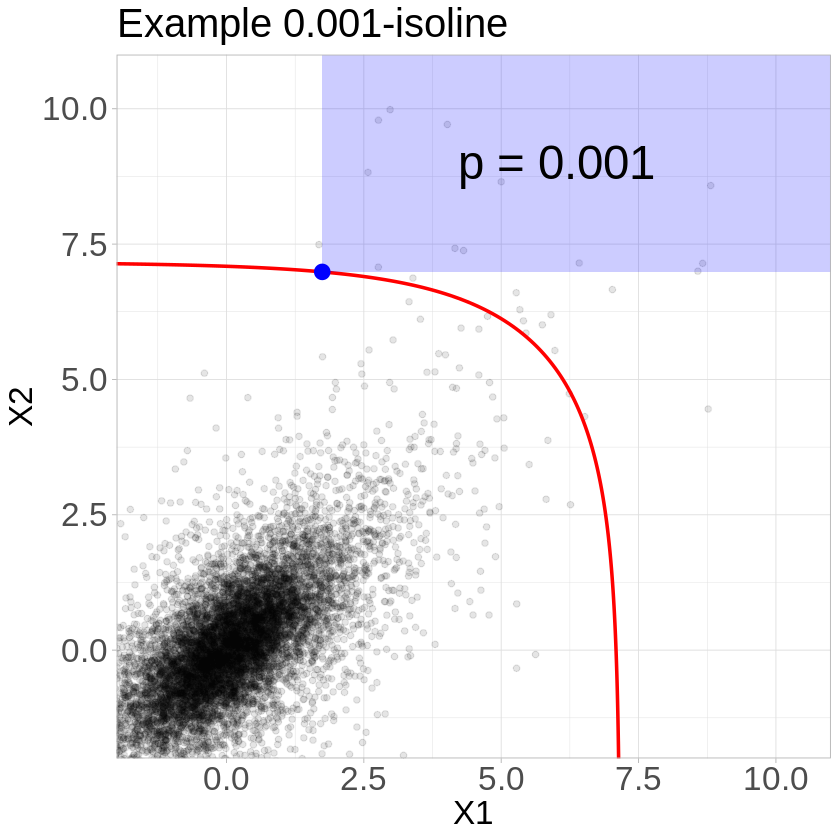

In [23]:
plt <- ggplot() + geom_point(data=multivariate_dat, aes(x=X1, y=X2), alpha=0.1) + geom_line(data=multivariate_isoline, aes(x=X1, y=X2), col='red', size=1) +
coord_cartesian(ylim=c(-2, 11), xlim = c(-2, 11), expand=0) + 
#annotate("rect", fill = "blue", alpha = 0.2, 
#        xmin = as.numeric(multivariate_isoline[150,])[1], xmax = 12,
#        ymin = as.numeric(multivariate_isoline[150,])[2], ymax = 12) +
#annotate("rect", fill = "blue", alpha = 0.2, 
#        xmin = as.numeric(multivariate_isoline[400,])[1], xmax = 12,
#        ymin = as.numeric(multivariate_isoline[400,])[2], ymax = 12) 
theme_light() +
ggtitle('Example 0.001-isoline') +
annotate("rect", fill = "blue", alpha = 0.2, 
        xmin = as.numeric(multivariate_isoline[150,])[1], xmax = 11,
        ymin = as.numeric(multivariate_isoline[150,])[2], ymax = 11) +
#annotate("rect", fill = "blue", alpha = 0.2, 
#        xmin = as.numeric(multivariate_isoline[50,])[1], xmax = 6,
#        ymin = as.numeric(multivariate_isoline[50,])[2], ymax = 6) +
annotate("text", x=6, y=9, label='p = 0.001', size=10) +
#annotate("text", x=5, y=2.5, label='p = 0.01', size=8) +
annotate("point", x = as.numeric(multivariate_isoline[150,])[1], y = as.numeric(multivariate_isoline[150,])[2], color = "blue", size = 4) +
theme(axis.title = element_text(size = 20), 
      axis.text = element_text(size = 20), 
      text = element_text(size = 20),
      plot.title = element_text(size=24))
plt
ggsave(filename='~/isolines_uq/outputs/plots/bivariate_isoline_ex.png', plot=plt, device='png', width=7, height=7)

In [34]:
gamma <- 1/3
extreme_isoline <- drawExtremeIsoline(multivariate_dat, 0.001, 100, c(-2,-2), gamma, 1/4)

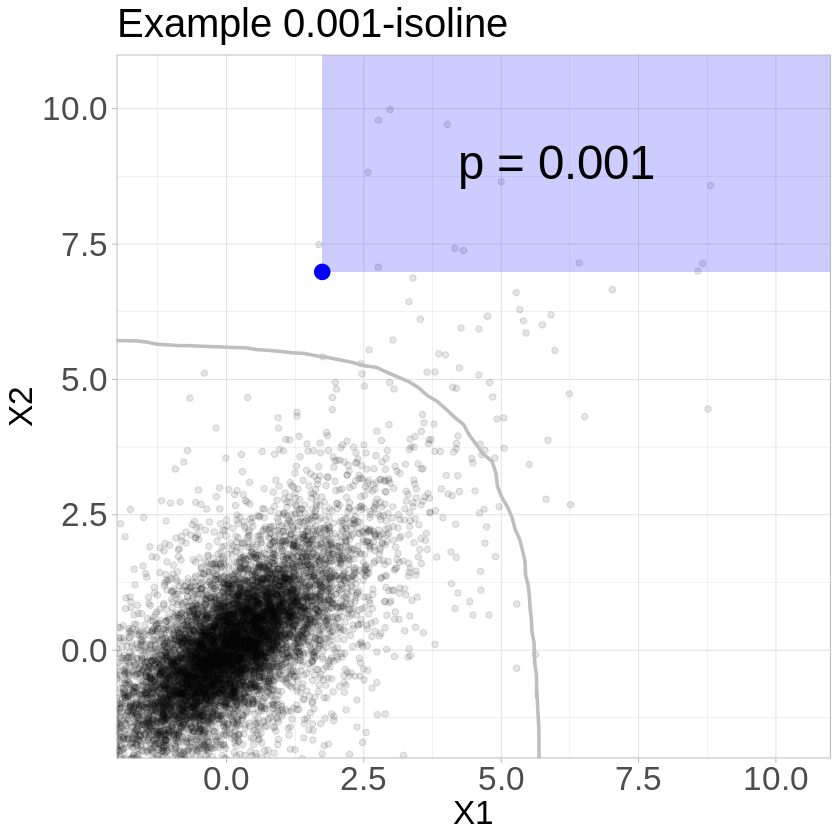

In [36]:
plt <- ggplot() + geom_point(data=multivariate_dat, aes(x=X1, y=X2), alpha=0.1) + 
geom_line(data=extreme_isoline, aes(x=X1, y=X2), col='gray', size=1) +
coord_cartesian(ylim=c(-2, 11), xlim = c(-2, 11), expand=0) + 
theme_light() +
ggtitle('Example 0.001-isoline') +
annotate("rect", fill = "blue", alpha = 0.2, 
        xmin = as.numeric(multivariate_isoline[150,])[1], xmax = 11,
        ymin = as.numeric(multivariate_isoline[150,])[2], ymax = 11) +
annotate("text", x=6, y=9, label='p = 0.001', size=10) +
#annotate("text", x=5, y=2.5, label='p = 0.01', size=8) +
annotate("point", x = as.numeric(multivariate_isoline[150,])[1], y = as.numeric(multivariate_isoline[150,])[2], color = "blue", size = 4) +
theme(axis.title = element_text(size = 20), 
      axis.text = element_text(size = 20), 
      text = element_text(size = 20),
      plot.title = element_text(size=24))
plt
ggsave(filename='~/isolines_uq/outputs/plots/bivariate_isoline_ex.png', plot=plt, device='png', width=7, height=7)

In [27]:
extreme_tube <- computeExtremeRegion(dat=multivariate_dat,
                                     alphas=c(0.05),
                                     p=0.001,
                                     B=1000,
                                     gamma=gamma,
                                     xi=1,
                                     progress_bar=TRUE)

  |======================================================================| 100%


X1,X2
<dbl>,<dbl>
1.900697116,1.93066729
-1.106672870,-0.17911909
-1.244520132,-0.18507519
0.369859676,0.76022022
-1.543755409,-1.15360677
-0.506419709,-0.95058293
-1.691399132,-1.55977024
1.086241785,0.18130629
0.036520256,-0.46021388
